In [66]:
import os

import your

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

In [21]:
def get_data_from_filterbank(filterbank_file, index, rand=0):
    steps = range(0, filterbank_file.your_header.nspectra, 256)
    return filterbank_file.get_data(nstart=steps[index]+rand, nsamp=256).T


def plot_images(filterbank_file, indexes):
        num_rows = 3
        num_cols = 3

        # Create a figure and axis objects
        fig, axs = plt.subplots(num_rows, num_cols, figsize=(10, 10))

        # Flatten the axis array to iterate over subplots
        axs = axs.flatten()

        # Loop through subplot data and plot each subplot
        for i, index in enumerate(indexes):
            axs[i].imshow(get_data_from_filterbank(filterbank_file, index), cmap='gray')

        # Adjust layout to prevent overlapping titles
        plt.tight_layout()

        # Show the plot
        plt.show()


def plot_individual_spec(filterbank_file, index, rand=0, sectors=None, sector_color='red', alpha=0.3):
    """
    Plot a single spectrogram and optionally shade sectors along OY (rows).
    sectors: None | [start,end] | [[s,e], [s2,e2], ...]
    sector_color: matplotlib color
    alpha: transparency 0..1
    """
    data = get_data_from_filterbank(filterbank_file, index, rand)
    nrows = data.shape[0]

    # Normalize sectors into a list of (start,end) pairs
    if sectors is None:
        sectors_list = []
    else:
        # accept single sector [a,b] or list of sectors [[a,b],...]
        try:
            first = sectors[0]
            if isinstance(first, (list, tuple)):
                sectors_list = [tuple(s) for s in sectors]
            else:
                sectors_list = [tuple(sectors)]
        except Exception:
            sectors_list = []

    # sanitize and clip to valid row range
    cleaned = []
    for s in sectors_list:
        try:
            a = int(s[0]); b = int(s[1])
        except Exception:
            continue
        if a > b:
            a, b = b, a
        a = max(0, a)
        b = min(nrows, b)
        if a < b:
            cleaned.append((a, b))
    sectors_list = cleaned

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(data, cmap='gray', aspect='auto', origin='upper')  # origin='lower' makes row 0 at bottom
    # overlay shaded sectors along Y axis
    for (a, b) in sectors_list:
        ax.axhspan(a, b, color=sector_color, alpha=alpha)

    ax.set_xlabel('OX (columns)')
    ax.set_ylabel('OY (rows)')
    ax.set_title(f'index={index}')
    plt.ylim
    plt.tight_layout()
    plt.show()

In [67]:
def compute_stats(x: np.ndarray, axis=None):
    """
    Возвращает mean, std, skew, kurt (excess) по заданной оси.
    skew и kurt считаем вручную, без scipy.
    """
    x = np.asarray(x)
    mean = x.mean(axis=axis, keepdims=True)
    std = x.std(axis=axis, keepdims=True)

    centered = x - mean
    m2 = (centered ** 2).mean(axis=axis, keepdims=True)
    m3 = (centered ** 3).mean(axis=axis, keepdims=True)
    m4 = (centered ** 4).mean(axis=axis, keepdims=True)

    std_safe = np.where(std == 0, 1.0, std)  # защита от деления на 0
    skew = m3 / (std_safe ** 3)
    kurt = m4 / (std_safe ** 4) - 3.0       # excess kurtosis

    return mean.squeeze(), std.squeeze(), skew.squeeze(), kurt.squeeze()


def normalize_per_channel(seg: np.ndarray) -> np.ndarray:
    """
    Нормализация каждого частотного канала (строки) в [0, 256].
    seg: (n_channels, n_time)
    """
    seg = np.asarray(seg)
    chan_min = seg.min(axis=1, keepdims=True)
    chan_max = seg.max(axis=1, keepdims=True)
    denom = chan_max - chan_min
    denom_safe = np.where(denom == 0, 1.0, denom)

    return (seg - chan_min) / denom_safe * 256.0


def compute_ratio(per_channel_vals: np.ndarray, seg_val: float) -> np.ndarray:
    """
    Отношение параметра канала к параметру всего сегмента.
    Если параметр сегмента == 0, возвращаем NaN.
    """
    per_channel_vals = np.asarray(per_channel_vals, dtype=float)
    if seg_val == 0:
        return np.full_like(per_channel_vals, np.nan, dtype=float)
    return per_channel_vals / seg_val


def get_rfi_block_id(segment_index: int, rfi_blocks_for_file: dict):
    """
    Находит номер RFI-блока, в диапазон которого попадает segment_index.
    rfi_blocks_for_file: {block_id: (start_segment, end_segment), ...}
    """
    for block_id, (start, end) in rfi_blocks_for_file.items():
        if start <= segment_index <= end:
            return block_id
    return None


def get_freq_ranges_for_block(block_id: int, segments_rfi_for_file: dict):
    """
    Возвращает список диапазонов частотных индексов для данного блока:
    [(start_idx, end_idx), ...]
    Учитывает оба варианта формата: [230, 256] и [[230, 235], [239, 241], ...].
    """
    vals = segments_rfi_for_file[block_id]
    # vals может быть [230, 256] или [[230, 235], [239, 241], ...]
    if isinstance(vals[0], (list, tuple, np.ndarray)):
        ranges = vals
    else:
        ranges = [vals]
    return [(int(s), int(e)) for (s, e) in ranges]


def build_rfi_mask(n_channels: int, freq_ranges):
    """
    Возвращает булевский вектор длины n_channels:
    True там, где канал попадает в диапазоны RFI.
    """
    mask = np.zeros(n_channels, dtype=bool)
    for start, end in freq_ranges:
        s = max(0, start)
        e = min(n_channels - 1, end)
        if s <= e:
            mask[s:e + 1] = True
    return mask

## Paths and constants

In [69]:
filterbank_file_path = '/hercules/results/akazantsev/filterbank_files/B0531+21/B0531+21_59000_48386.fil'


frequency_range = {
    'B0531+21_59000_48386.fil': np.linspace(1530.0, 1210.0, 256)
}

rfi_blocks = {
    'B0531+21_59000_48386.fil': {
        1: (204,1527,),
        2: (2023, 4436,),
        3: (4437, 4953,),
        4: (6701, 7631,),
        5: (42546, 45015,),
        6: (45622, 45705,),
        7: (46186, 46927,),
        8: (46928, 47303,),
        9: (48686, 48831,),
        10: (48832, 49591,)
    }
}

segments_rfi_indexes = {
    'B0531+21_59000_48386.fil': {
        1: [[230, 235], [239, 241]],
        2: [230, 256],
        3: [230, 256],
        4: [[230,235], [239, 243]],
        5: [[189, 195], [199, 202], [205, 209]],
        6: [[189, 195], [199, 202], [206, 210]],
        7: [[190, 193], [199, 202], [206, 210]],
        8: [[188, 194], [198, 203], [206, 210]],
        9: [[188, 194], [198, 203], [206, 210]],
        10: [[188, 194], [198, 203], [206, 210]]
    }
}

In [25]:
filterbank_file = your.Your(filterbank_file_path) 
labels = pd.read_csv('segments_index_B0531+21_59000_48386.csv')

In [12]:
filterbank_file.your_header

Unified Header:
  "basename": "B0531+21_59000_48386"
  "bw": -320.0
  "center_freq": 1370.625
  "dec_deg": null
  "dtype": "uint8"
  "fch1": 1530.0
  "filelist": [
    "/hercules/results/akazantsev/filterbank_files/B0531+21/B0531+21_59000_48386.fil"
  ]
  "filename": "/hercules/results/akazantsev/filterbank_files/B0531+21/B0531+21_59000_48386.fil"
  "foff": -1.25
  "format": "fil"
  "frequency_decimation_factor": 1
  "gb": null
  "gl": null
  "native_foff": -1.25
  "native_nbits": 8
  "native_nchans": 256
  "native_nspectra": 12818359.0
  "native_tsamp": 0.0001024
  "nbits": 8
  "nchans": 256
  "npol": 1
  "nspectra": 12818359
  "poln_order": "I"
  "ra_deg": null
  "source_name": "B1937+21"
  "time_decimation_factor": 1
  "tsamp": 0.0001024
  "tstart": 59000.48386574074
  "tstart_utc": "2020-05-31T11:36:46.000"

In [65]:
set(labels['label'])

{'BB+NB', 'BB+P', 'NB+P', 'bright_BBRFI', 'bright_NBRFI', 'bright_pulses', nan}

In [16]:
spec = get_data_from_filterbank(filterbank_file, 204, rand=0)


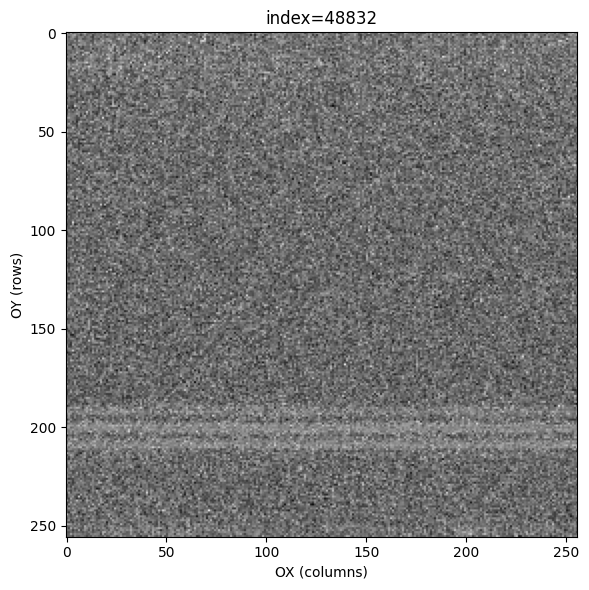

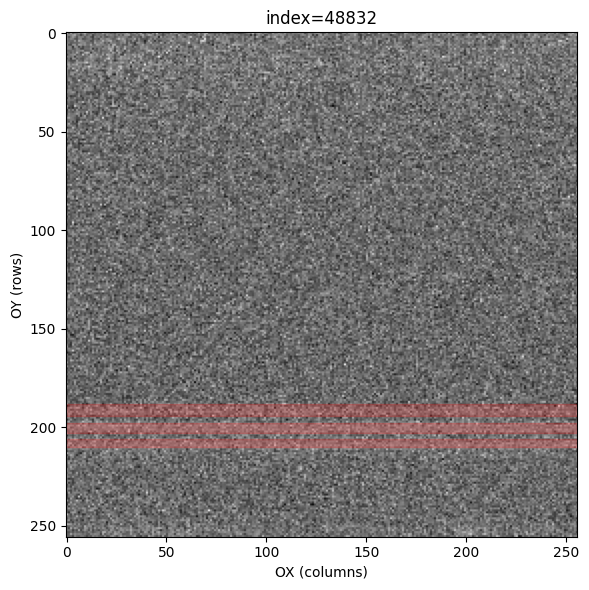

In [64]:
idx = 48832
plot_individual_spec(filterbank_file, idx, rand=0, sectors=None, sector_color='red', alpha=0.3)
plot_individual_spec(filterbank_file, idx, rand=0, sectors=[[188, 194], [198, 203], [206, 210]], sector_color='red', alpha=0.2)

In [70]:
file_key = os.path.basename(filterbank_file_path)              # 'B0531+21_59000_48386.fil'
freqs = frequency_range[file_key]                              # массив из 256 частот
rfi_blocks_file = rfi_blocks[file_key]
segments_rfi_file = segments_rfi_indexes[file_key]

all_channels = []   # сюда складываем сами частотные каналы (временные ряды)
meta_rows = []      # сюда — строки таблички с параметрами

# Нас интересуют только NaN и bright_NBRFI
interesting = labels[labels['label'].isna() |
                     (labels['label'] == 'bright_NBRFI')]

# На случай, если вдруг не будет ни одного сегмента
n_time_default = 256

for _, row in tqdm(interesting.iterrows(),
                   total=len(interesting),
                   desc='Processing segments'):
    seg_idx = int(row['segment_index'])
    glob_idx = int(row['global_index'])
    orig_label = row['label']

    # Определяем тип сегмента и RFI-блок (если нужен)
    if pd.isna(orig_label):
        segment_type = 'nan'
        rfi_block_id = None
    elif orig_label == 'bright_NBRFI':
        segment_type = 'bright_NBRFI'
        rfi_block_id = get_rfi_block_id(seg_idx, rfi_blocks_file)
        # Если сегмент не попадает ни в один диапазон rfi_blocks — пропускаем
        if rfi_block_id is None:
            continue
    else:
        # На всякий случай, но сюда мы не должны попасть после фильтра "interesting"
        continue

    # Считываем сегмент: (n_channels, n_time) = (256, 256)
    seg = get_data_from_filterbank(filterbank_file, seg_idx, rand=0)
    seg = np.asarray(seg)
    n_channels, n_time = seg.shape
    n_time_default = n_time  # запомним реальную длину сегмента

    # --- Статистика по всему сегменту (оригинальные данные) ---
    mean_o_seg, std_o_seg, skew_o_seg, kurt_o_seg = compute_stats(seg)

    # --- Нормализация каждого канала в [0, 256] ---
    seg_norm = normalize_per_channel(seg)

    # --- Статистика по всему сегменту (нормализованные данные) ---
    mean_n_seg, std_n_seg, skew_n_seg, kurt_n_seg = compute_stats(seg_norm)

    # --- Статистика по отдельным каналам (оригинал и нормализованный) ---
    # axis=1 => считаем по времени для каждой частоты
    mean_o_chan, std_o_chan, skew_o_chan, kurt_o_chan = compute_stats(seg, axis=1)
    mean_n_chan, std_n_chan, skew_n_chan, kurt_n_chan = compute_stats(seg_norm, axis=1)

    # --- Отношения "канал / весь сегмент" ---
    mean_o_ratio = compute_ratio(mean_o_chan, mean_o_seg)
    std_o_ratio  = compute_ratio(std_o_chan, std_o_seg)
    skew_o_ratio = compute_ratio(skew_o_chan, skew_o_seg)
    kurt_o_ratio = compute_ratio(kurt_o_chan, kurt_o_seg)

    mean_n_ratio = compute_ratio(mean_n_chan, mean_n_seg)
    std_n_ratio  = compute_ratio(std_n_chan, std_n_seg)
    skew_n_ratio = compute_ratio(skew_n_chan, skew_n_seg)
    kurt_n_ratio = compute_ratio(kurt_n_chan, kurt_n_seg)

    # --- Лейблы для каналов ---
    if segment_type == 'nan':
        # Если исходный label NaN — оставляем NaN для всех каналов
        channel_labels = [np.nan] * n_channels
    else:
        # segment_type == 'bright_NBRFI' и сегмент внутри rfi_blocks
        freq_ranges = get_freq_ranges_for_block(rfi_block_id, segments_rfi_file)
        rfi_mask = build_rfi_mask(n_channels, freq_ranges)
        channel_labels = ['NBRFI' if is_rfi else 'NoneWNBRFI'
                          for is_rfi in rfi_mask]

    # --- Проход по всем частотным каналам сегмента ---
    for ch_idx in range(n_channels):
        # порядковый индекс образца в общем массиве
        sample_index = len(all_channels)

        # сам временной ряд канала
        ch_series = seg[ch_idx]
        all_channels.append(ch_series.astype(np.float32))

        # строка метаданных
        meta_rows.append({
            'sample_index': sample_index,          # индекс → строка в npy
            'global_index': glob_idx,
            'segment_index': seg_idx,
            'channel_index': ch_idx,
            'frequency': float(freqs[ch_idx]),

            'mean_o': float(mean_o_chan[ch_idx]),
            'std_o': float(std_o_chan[ch_idx]),
            'skew_o': float(skew_o_chan[ch_idx]),
            'kurt_o': float(kurt_o_chan[ch_idx]),

            'mean_n': float(mean_n_chan[ch_idx]),
            'std_n': float(std_n_chan[ch_idx]),
            'skew_n': float(skew_n_chan[ch_idx]),
            'kurt_n': float(kurt_n_chan[ch_idx]),

            'mean_o_ratio': float(mean_o_ratio[ch_idx]),
            'std_o_ratio': float(std_o_ratio[ch_idx]),
            'skew_o_ratio': float(skew_o_ratio[ch_idx]),
            'kurt_o_ratio': float(kurt_o_ratio[ch_idx]),

            'mean_n_ratio': float(mean_n_ratio[ch_idx]),
            'std_n_ratio': float(std_n_ratio[ch_idx]),
            'skew_n_ratio': float(skew_n_ratio[ch_idx]),
            'kurt_n_ratio': float(kurt_n_ratio[ch_idx]),

            'label': channel_labels[ch_idx],       # NaN / NBRFI / NoneWNBRFI
            'original_segment_label': orig_label   # исходный label сегмента
        })

# -------------------------- финальное сохранение -------------------------- #

if all_channels:
    channels_array = np.stack(all_channels, axis=0)  # shape = (N_каналов, 256)
else:
    channels_array = np.empty((0, n_time_default), dtype=np.float32)

meta_df = pd.DataFrame(meta_rows)

# Имена файлов по имени .fil
base_name = os.path.splitext(os.path.basename(filterbank_file_path))[0]
channels_npy_path = f'{base_name}_channels.npy'
meta_csv_path = f'{base_name}_channels_meta.csv'

np.save(channels_npy_path, channels_array)
meta_df.to_csv(meta_csv_path, index=False)

print('Готово ✅')
print('Массив каналов:', channels_array.shape)
print('Число строк в таблице:', len(meta_df))
print('Файлы сохранены как:')
print('  ', channels_npy_path)
print('  ', meta_csv_path)

Processing segments:   0%|          | 0/26656 [00:00<?, ?it/s]

Готово ✅
Массив каналов: (6823936, 256)
Число строк в таблице: 6823936
Файлы сохранены как:
   B0531+21_59000_48386_channels.npy
   B0531+21_59000_48386_channels_meta.csv
